In [ ]:
# Hücre – Kütüphaneler ve Path Tanımı

import os
import random
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from tqdm import tqdm

BASE_DIR = "Dataset"
SPLITS = ["training", "validation", "test"]

print("Hazır.")

Hazır.


In [ ]:
# Hücre – Split İçindeki Dosya Sayıları

def count_files():
    stats = {}
    
    for split in SPLITS:
        img_dir = os.path.join(BASE_DIR, split, "images")
        lbl_dir = os.path.join(BASE_DIR, split, "labels")
        
        img_count = len(os.listdir(img_dir))
        lbl_count = len(os.listdir(lbl_dir))
        
        stats[split] = {
            "images": img_count,
            "labels": lbl_count
        }
        
    return stats

stats = count_files()
stats

{'training': {'images': 2024, 'labels': 2024},
 'validation': {'images': 182, 'labels': 182},
 'test': {'images': 182, 'labels': 182}}

In [ ]:
# Hücre – Eksik Image / Label Kontrolü

def check_missing_pairs():
    problems = []

    for split in SPLITS:
        img_dir = os.path.join(BASE_DIR, split, "images")
        lbl_dir = os.path.join(BASE_DIR, split, "labels")

        images = {os.path.splitext(f)[0] for f in os.listdir(img_dir)}
        labels = {os.path.splitext(f)[0] for f in os.listdir(lbl_dir)}

        missing_labels = images - labels
        missing_images = labels - images

        if missing_labels:
            problems.append((split, "Missing labels", len(missing_labels)))
        if missing_images:
            problems.append((split, "Missing images", len(missing_images)))

    return problems

check_missing_pairs()

[]

In [4]:
# Hücre – Class Distribution Analizi

def get_class_distribution():
    class_counts = Counter()

    for split in SPLITS:
        lbl_dir = os.path.join(BASE_DIR, split, "labels")
        
        for file in tqdm(os.listdir(lbl_dir)):
            with open(os.path.join(lbl_dir, file), "r") as f:
                lines = f.readlines()
                for line in lines:
                    cls = int(line.split()[0])
                    class_counts[cls] += 1

    return class_counts

class_counts = get_class_distribution()
class_counts

100%|██████████| 182/182 [00:00<00:00, 39599.70it/s]


Counter({5: 8250, 4: 7610, 3: 6770, 6: 3811, 0: 2388, 1: 2388, 2: 2231})

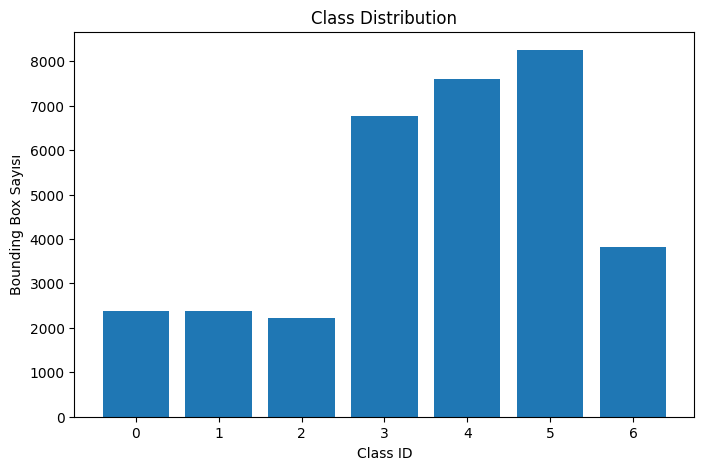

In [5]:
# Hücre – Class Distribution Grafiği

plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class ID")
plt.ylabel("Bounding Box Sayısı")
plt.title("Class Distribution")
plt.show()

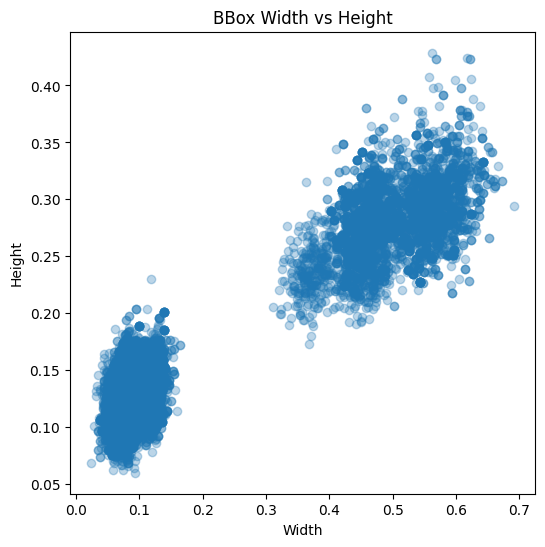

In [6]:
# Hücre – Bounding Box Boyut Analizi

def analyze_bbox_sizes():
    widths = []
    heights = []

    for split in SPLITS:
        lbl_dir = os.path.join(BASE_DIR, split, "labels")
        
        for file in os.listdir(lbl_dir):
            with open(os.path.join(lbl_dir, file), "r") as f:
                lines = f.readlines()
                for line in lines:
                    parts = line.split()
                    widths.append(float(parts[3]))
                    heights.append(float(parts[4]))

    return widths, heights

w, h = analyze_bbox_sizes()

plt.figure(figsize=(6,6))
plt.scatter(w, h, alpha=0.3)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("BBox Width vs Height")
plt.show()

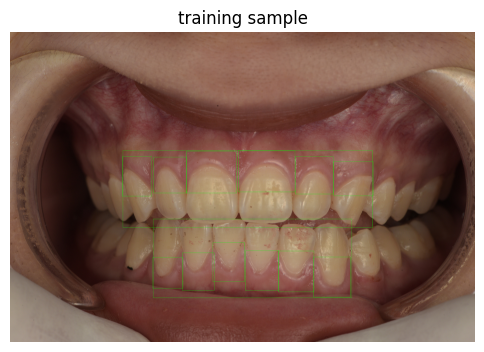

In [7]:
# Hücre – Rastgele Görsel + Label Görselleştirme

def show_random_sample(split="training"):
    img_dir = os.path.join(BASE_DIR, split, "images")
    lbl_dir = os.path.join(BASE_DIR, split, "labels")

    file = random.choice(os.listdir(img_dir))
    name = os.path.splitext(file)[0]

    img = cv2.imread(os.path.join(img_dir, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h_img, w_img = img.shape[:2]

    with open(os.path.join(lbl_dir, name + ".txt"), "r") as f:
        lines = f.readlines()

    for line in lines:
        cls, xc, yc, bw, bh = map(float, line.split())
        
        x1 = int((xc - bw/2) * w_img)
        y1 = int((yc - bh/2) * h_img)
        x2 = int((xc + bw/2) * w_img)
        y2 = int((yc + bh/2) * h_img)

        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{split} sample")
    plt.show()

show_random_sample("training")

In [1]:
from ultralytics import YOLO
model = YOLO('runs/detect/dental_strong_m_v4/weights/best.pt')
metrics = model.val(data='dataset.yaml', split='val')
print(metrics)

Ultralytics YOLOv8.0.196 🚀 Python-3.10.19 torch-2.3.1+cu121 CUDA:0 (Quadro RTX 4000, 7752MiB)
Model summary (fused): 218 layers, 25843813 parameters, 0 gradients, 78.7 GFLOPs
val: Scanning /home/bkkarakoc/dis_eti/Dataset/validation/labels.cache... 182 images, 0 backgrounds, 0 corrupt: 100%|██████████| 182/182 [00:00<?, ?it/s]
val: WARNING ⚠️ /home/bkkarakoc/dis_eti/Dataset/validation/images/00811.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:14<00:00,  1.17s/it]
                   all        182       2548      0.537      0.651      0.546      0.372
                saglam        182        182      0.996          1      0.995      0.838
      hafif_gingivitis        182        182      0.995          1      0.995      0.788
      ileri_gingivitis        182         30      0.147      0.267      0.129     0.0699
         periodontitis        182        306      0.206      0.261      0.

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79d604797d00>
fitness: 0.38948331053571833
keys: ['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']
maps: array([    0.83834,     0.78847,    0.069858,    0.090385,      0.2378,     0.23488,      0.3451])
names: {0: 'saglam', 1: 'hafif_gingivitis', 2: 'ileri_gingivitis', 3: 'periodontitis', 4: 'plak', 5: 'tartar', 6: 'kanama'}
plot: True
results_dict: {'metrics/precision(B)': 0.5369188630525618, 'metrics/recall(B)': 0.6507272962183867, 'metrics/mAP50(B)': 0.5457520739238757, 'metrics/mAP50-95(B)': 0.3721201146037008, 'fitness': 0.38948331053571833}
save_dir: PosixPath('runs/detect/val')
speed: {'preprocess': 1.0251357005192685, 'inference': 19.26453165955596, 'loss': 0.00968739226624206, 'postprocess': 2.5602015820178354}


In [3]:
from collections import Counter
from pathlib import Path

names = {0:'saglam', 1:'hafif_gingivitis', 2:'ileri_gingivitis', 
         3:'periodontitis', 4:'plak', 5:'tartar', 6:'kanama'}

for split in ['training', 'validation', 'test']:
    counts = Counter()
    for lf in Path(f'Dataset/{split}/labels').glob('*.txt'):
        for line in lf.read_text().splitlines():
            if line.strip():
                counts[int(line.split()[0])] += 1
    print(f'\n=== {split} ===')
    for cid, name in names.items():
        print(f'  {name:25s}: {counts.get(cid, 0)}')



=== training ===
  saglam                   : 2024
  hafif_gingivitis         : 2024
  ileri_gingivitis         : 2166
  periodontitis            : 6157
  plak                     : 5937
  tartar                   : 6782
  kanama                   : 3270

=== validation ===
  saglam                   : 182
  hafif_gingivitis         : 182
  ileri_gingivitis         : 30
  periodontitis            : 306
  plak                     : 774
  tartar                   : 755
  kanama                   : 320

=== test ===
  saglam                   : 182
  hafif_gingivitis         : 182
  ileri_gingivitis         : 35
  periodontitis            : 307
  plak                     : 899
  tartar                   : 713
  kanama                   : 221


In [4]:
from pathlib import Path
from collections import Counter

# Kac goruntude ileri_gingivitis var?
for split in ['training', 'validation', 'test']:
    count = 0
    for lf in Path(f'Dataset/{split}/labels').glob('*.txt'):
        for line in lf.read_text().splitlines():
            if line.strip() and int(line.split()[0]) == 2:
                count += 1
                break  # goruntu basina 1 say
    print(f'{split}: {count} goruntu ileri_gingivitis iceriyor')

training: 921 goruntu ileri_gingivitis iceriyor
validation: 15 goruntu ileri_gingivitis iceriyor
test: 17 goruntu ileri_gingivitis iceriyor
